In [1]:
# Import Required Libraries
import qiskit
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()
print(simulator)


Qiskit Version: 2.5.1
AerSimulator('aer_simulator')


In [2]:
def xor_bits(a, b):
    return ''.join(str(int(x) ^ int(y)) for x, y in zip(a, b))


def dot_mod2(a, b):
    return sum(int(x) * int(y) for x, y in zip(a, b)) % 2


def make_simon_mapping(secret):
    # Builds pairs x and x XOR s.
    # Each pair receives the same output label.
    n = len(secret)
    strings = [''.join(bits) for bits in product('01', repeat=n)]

    if set(secret) == {'0'}:
        return {x: x for x in strings}

    mapping = {}
    output_id = 0

    for x in strings:
        if x not in mapping:
            partner = xor_bits(x, secret)
            label = format(output_id, f'0{n}b')
            mapping[x] = label
            mapping[partner] = label
            output_id += 1

    return mapping


def build_simon_oracle(secret):
    # Reversible permutation oracle using 2n qubits.
    # First n qubits = input register, next n = output register.
    n = len(secret)
    mapping = make_simon_mapping(secret)
    qc = QuantumCircuit(2*n, name=f"Oracle_s_{secret}")

    # For each computational basis input x, conditionally XOR f(x)
    # into the output register.
    for x, fx in mapping.items():
        for i, bit in enumerate(fx):
            if bit == '1':
                # Select x using open controls where necessary.
                for j, xbit in enumerate(x):
                    if xbit == '0':
                        qc.x(j)
                qc.mcx(list(range(n)), n+i)
                for j, xbit in enumerate(x):
                    if xbit == '0':
                        qc.x(j)

    return qc, mapping


def simon_circuit(secret, shots=2048):
    n = len(secret)
    oracle, mapping = build_simon_oracle(secret)

    qc = QuantumCircuit(2*n, n)
    qc.h(range(n))
    qc.compose(oracle, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))

    counts = simulator.run(qc, shots=shots).result().get_counts()
    return qc, counts, mapping


def gf2_rank(rows):
    rows = [list(map(int, r)) if isinstance(r, str) else list(r) for r in rows if any(map(int, r))]
    if not rows:
        return 0

    A = np.array(rows, dtype=np.uint8) % 2
    rank = 0
    m, n = A.shape

    for col in range(n):
        pivot = next((r for r in range(rank, m) if A[r, col]), None)
        if pivot is None:
            continue
        A[[rank, pivot]] = A[[pivot, rank]]
        for r in range(m):
            if r != rank and A[r, col]:
                A[r] ^= A[rank]
        rank += 1
        if rank == m:
            break
    return rank


def independent_equations(counts, n):
    equations = []
    for y in sorted(counts, key=counts.get, reverse=True):
        # Qiskit count strings are displayed as c[n-1]...c[0].
        if y == '0'*n:
            continue
        if gf2_rank(equations + [y]) > gf2_rank(equations):
            equations.append(y)
        if len(equations) == n - 1:
            break
    return equations


def solve_simon_secret(equations, n):
    # Search all candidate strings satisfying y.s = 0 mod 2.
    candidates = []
    for bits in product('01', repeat=n):
        s = ''.join(bits)
        if all(dot_mod2(y, s) == 0 for y in equations):
            candidates.append(s)

    nonzero = [s for s in candidates if s != '0'*n]
    if len(nonzero) == 1:
        return nonzero[0]
    return '0'*n


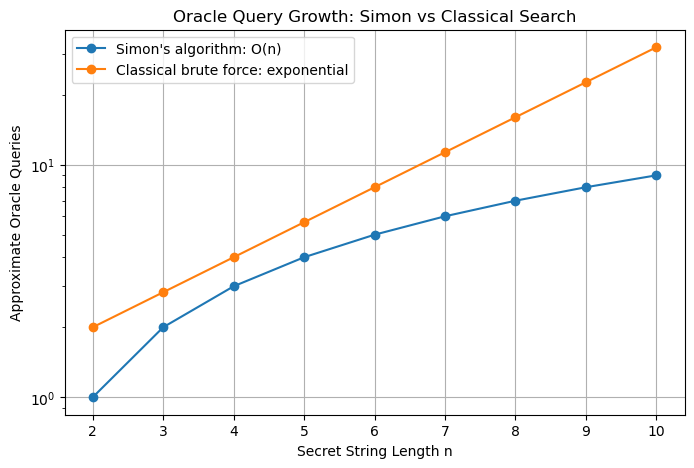

n | Quantum | Approx. Classical
--------------------------------
 2 |       1 |               2.00
 3 |       2 |               2.83
 4 |       3 |               4.00
 5 |       4 |               5.66
 6 |       5 |               8.00
 7 |       6 |              11.31
 8 |       7 |              16.00
 9 |       8 |              22.63
10 |       9 |              32.00


In [3]:
# Conceptual query-complexity comparison.
# Simon's algorithm needs O(n) oracle queries.
# A classical brute-force search has exponential query complexity.

n_values = np.arange(2, 11)
quantum_queries = n_values - 1
classical_queries = 2 ** (n_values / 2)

plt.figure(figsize=(8, 5))
plt.plot(n_values, quantum_queries, marker="o", label="Simon's algorithm: O(n)")
plt.plot(n_values, classical_queries, marker="o", label="Classical brute force: exponential")
plt.xlabel("Secret String Length n")
plt.ylabel("Approximate Oracle Queries")
plt.title("Oracle Query Growth: Simon vs Classical Search")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()

print("n | Quantum | Approx. Classical")
print("-" * 32)
for n, q, c in zip(n_values, quantum_queries, classical_queries):
    print(f"{n:2} | {q:7} | {c:18.2f}")
